/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Gate vocab: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Train nets: 24 | Test nets: 6
Built 24 train + 6 test joint graphs.
Final input dim: 35
Train graphs: 24 | Test graphs: 6
Class weights: [1.3747077  0.00848948 1.3747077  1.2420951 ]
[Epoch 01] train_loss=0.7607 train_acc=0.4783 val_loss=1.7195 val_acc=0.3379
[Epoch 05] train_loss=0.2968 train_acc=0.8481 val_loss=0.8182 val_acc=0.8744
[Epoch 10] train_loss=0.2496 train_acc=0.9224 val_loss=0.5166 val_acc=0.9755
[Epoch 15] train_loss=0.2323 train_acc=0.9391 val_loss=0.3856 val_acc=0.9867
[Epoch 20] train_loss=0.1968 train_acc=0.9527 val_loss=0.6673 val_acc=0.9884
[Epoch 25] train_loss=0.2229 train_acc=0.9513 val_loss=0.6337 val_acc=0.9911
[Epoch 30] train_loss=0.1923 train_acc=0.9562 val_loss=0.1514 val_acc=0.9937
[Epoch 35] train_loss=0.2076 train_acc=0.9526 val_loss=0.3275 val_acc=0.9933
[Epoch 40] train_loss=0.1799 train_acc=0.9582 val_loss=0.1853 val_acc=0.

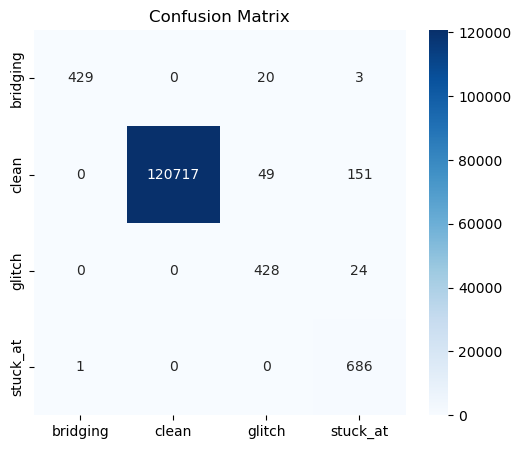

Using GNNExplainer import: explain.GNNExplainer


SystemExit: Failed to instantiate GNNExplainer: GNNExplainer.__init__() got multiple values for argument 'epochs'

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
# ===========================
# End-to-end: Training + Eval + Relational prototypes + GNNExplainer comparison
# ===========================

import math, json, os, sys
from collections import defaultdict, deque
from pathlib import Path
import numpy as np
import pandas as pd
import time

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Config (tweak as needed)
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"
EPOCHS = 50
LR = 7e-4
BATCH_SIZE = 1
DROPOUT = 0.4
HID = 64
HEADS1 = 4
HEADS2 = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------
# Load CSVs
# -------------------------
nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

# basic sanity check (same names as used earlier)
need_node_cols = [
    "netlist_file","fault_type","node_id","gate_type","label",
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]
for c in need_node_cols:
    if c not in nodes_df.columns:
        raise SystemExit(f"Missing column in nodes CSV: {c}")

need_edge_cols = ["netlist_file","fault_type","src_node","dst_node"]
for c in need_edge_cols:
    if c not in edges_df.columns:
        raise SystemExit(f"Missing column in edges CSV: {c}")

# -------------------------
# Label encoding & gate one-hot (same logic as before)
# -------------------------
le = LabelEncoder()
nodes_df["cls"] = le.fit_transform(nodes_df["fault_type"])
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

logic_gate_whitelist = {"and","nand","nor","not","or","xor","buf","pi","po","PI","PO"}
gate_norm = nodes_df["gate_type"].astype(str).str.lower()
gate_norm = gate_norm.where(gate_norm.isin(logic_gate_whitelist), other="other")
gate_vocab = sorted(gate_norm.unique().tolist())
g2i = {g:i for i,g in enumerate(gate_vocab)}
nodes_df["gate_oh_idx"] = gate_norm.map(g2i)
G = len(gate_vocab)
print("Gate vocab:", gate_vocab)

base_num_cols = [
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]
B = len(base_num_cols)

# -------------------------
# Split by netlist
# -------------------------
netlists = nodes_df["netlist_file"].drop_duplicates().values
train_nets, test_nets = train_test_split(netlists, test_size=0.2, random_state=42, shuffle=True)
print(f"Train nets: {len(train_nets)} | Test nets: {len(test_nets)}")

# -------------------------
# Build joint graphs (identical to your working builder)
# -------------------------
def build_joint_graphs(nets):
    graphs = []
    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf]
        if nd_sub.empty:
            continue
        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid:i for i,nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_edges = edges_df[(edges_df["netlist_file"]==nf) & (edges_df["fault_type"]=="clean")]
        if not clean_edges.empty:
            ee = clean_edges
        else:
            ee = edges_df[edges_df["netlist_file"]==nf][["src_node","dst_node"]].drop_duplicates()

        src, dst = [], []
        for _, r in ee.iterrows():
            s, d = r["src_node"], r["dst_node"]
            if s in id2idx and d in id2idx:
                src.append(id2idx[s]); dst.append(id2idx[d])
        edge_index = torch.tensor([src, dst], dtype=torch.long) if len(src) else torch.empty((2,0), dtype=torch.long)

        gt_map = {}
        clean_nodes = nd_sub[nd_sub["fault_type"]=="clean"]
        if not clean_nodes.empty:
            for _, r in clean_nodes.iterrows():
                gt_map[r["node_id"]] = r["gate_type"]
        else:
            first = nd_sub.sort_values("fault_type").drop_duplicates("node_id", keep="first")
            gt_map = dict(zip(first["node_id"], first["gate_type"]))

        gate_oh = np.zeros((N, G), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            gname = str(gt_map.get(nid, "other")).lower()
            gname = gname if gname in g2i else "other"
            gate_oh[i, g2i[gname]] = 1.0

        nums = np.zeros((N, len(base_num_cols)), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            rows = nd_sub[nd_sub["node_id"]==nid]
            row = rows[rows["fault_type"]=="clean"]
            if row.empty:
                row = rows.iloc[[0]]
            nums[i,:] = row[base_num_cols].astype(np.float32).values[0]

        y = np.full(N, fill_value=class_names.index("clean") if "clean" in class_names else 0, dtype=np.int64)
        for ft in class_names:
            if ft == "clean":
                continue
            sub = nd_sub[nd_sub["fault_type"]==ft]
            if sub.empty:
                continue
            faulty_nodes = sub[sub["label"]==1]["node_id"].values
            for nid in faulty_nodes:
                if nid in id2idx:
                    y[id2idx[nid]] = class_names.index(ft)

        data = Data(
            x=torch.from_numpy(np.concatenate([gate_oh, nums], axis=1)),
            edge_index=edge_index,
            y=torch.from_numpy(y),
        )
        data.netlist_file = nf
        data.node_ids = node_ids
        graphs.append(data)
    return graphs

train_graphs = build_joint_graphs(train_nets)
test_graphs  = build_joint_graphs(test_nets)
print(f"Built {len(train_graphs)} train + {len(test_graphs)} test joint graphs.")

# -------------------------
# Append relational features (exactly as before)
# -------------------------
num_start = G
idx_CC0 = num_start + base_num_cols.index("CC0_exact")
idx_CC1 = num_start + base_num_cols.index("CC1_exact")
idx_CO  = num_start + base_num_cols.index("CO_exact")
idx_path = num_start + base_num_cols.index("path_depth")
idx_distPO = num_start + base_num_cols.index("dist_to_PO")

def build_adj_lists(edge_index, N):
    src = edge_index[0].cpu().numpy().tolist() if edge_index.numel() else []
    dst = edge_index[1].cpu().numpy().tolist() if edge_index.numel() else []
    out_adj = [[] for _ in range(N)]
    in_adj  = [[] for _ in range(N)]
    for s,d in zip(src,dst):
        out_adj[s].append(d)
        in_adj[d].append(s)
    return in_adj, out_adj

def k_hop_unique_counts(start_nodes, adj, K=3):
    N = len(adj)
    out = np.zeros(N, dtype=np.int32)
    for u in range(N):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen and w != u:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier:
                break
        out[u] = len(seen)
    return out

def neighbor_mean(arr, adj):
    N = len(adj)
    out = np.zeros(N, dtype=np.float32)
    for u in range(N):
        neigh = adj[u]
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])
    return out

def append_relational_features(data: Data):
    x = data.x.clone().float()
    N = x.size(0)
    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co  = x[:, idx_CO ].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean  = neighbor_mean(co,  in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean  = neighbor_mean(co, out_adj)

    cc0_in_delta  = cc0 - cc0_in_mean
    cc1_in_delta  = cc1 - cc1_in_mean
    co_in_delta   = co  - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta  = co  - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.int32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.int32)
    in_k2 = k_hop_unique_counts(range(N), in_adj, K=2)
    out_k2 = k_hop_unique_counts(range(N), out_adj, K=2)
    in_k3 = k_hop_unique_counts(range(N), in_adj, K=3)
    out_k3 = k_hop_unique_counts(range(N), out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()
    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    def count_reach(u, targets, adj, K=3):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier:
                break
        return sum(1 for w in seen if w in targets)

    pi_anc3 = np.zeros(N, dtype=np.int32)
    po_des3 = np.zeros(N, dtype=np.int32)
    for u in range(N):
        pi_anc3[u] = count_reach(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reach(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean,  cc1_in_mean,  co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta,cc1_out_delta,co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data

for lst in (train_graphs, test_graphs):
    for i in range(len(lst)):
        lst[i] = append_relational_features(lst[i])

# -------------------------
# Normalize numeric columns (train-only stats)
# -------------------------
num_slice_start = G
num_dim = train_graphs[0].x.size(1) - G

def fit_norm(graphs):
    X = torch.cat([g.x[:, num_slice_start:] for g in graphs], dim=0).float().cpu().numpy()
    mean = X.mean(axis=0); std = X.std(axis=0) + 1e-6
    return mean.astype(np.float32), std.astype(np.float32)

mu, sigma = fit_norm(train_graphs)

def apply_norm(graphs, mu, sigma):
    for g in graphs:
        nums = g.x[:, num_slice_start:].float().cpu().numpy()
        nums = (nums - mu) / sigma
        g.x[:, num_slice_start:] = torch.from_numpy(nums).float()
    return graphs

train_graphs = apply_norm(train_graphs, mu, sigma)
test_graphs  = apply_norm(test_graphs,  mu, sigma)

print("Final input dim:", train_graphs[0].x.size(1))
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# -------------------------
# NodeGAT model (same as yours)
# -------------------------
class NodeGAT(nn.Module):
    def __init__(self, in_dim, hid=64, out_dim=4, heads1=4, heads2=4, dropout=0.4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hid, heads=heads1, dropout=dropout, concat=True)
        self.gat2 = GATConv(hid*heads1, hid, heads=heads2, dropout=dropout, concat=False)
        self.ln1 = nn.LayerNorm(hid*heads1)
        self.ln2 = nn.LayerNorm(hid)
        self.res1 = nn.Linear(in_dim, hid*heads1)
        self.res2 = nn.Linear(hid*heads1, hid)
        self.dropout = nn.Dropout(dropout)
        self.cls = nn.Linear(hid, out_dim)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h1 = self.gat1(x, ei)
        h1 = self.ln1(h1 + self.res1(x))
        h1 = F.elu(h1)
        h1 = self.dropout(h1)

        h2 = self.gat2(h1, ei)
        h2 = self.ln2(h2 + self.res2(h1))
        h2 = F.elu(h2)
        h2 = self.dropout(h2)

        return self.cls(h2)

in_dim = train_graphs[0].x.size(1)
model = NodeGAT(in_dim=in_dim, hid=HID, out_dim=num_classes,
                heads1=HEADS1, heads2=HEADS2, dropout=DROPOUT).to(DEVICE)

# -------------------------
# Loss & Optimizer
# -------------------------
train_labels_all = np.concatenate([g.y.numpy() for g in train_graphs], axis=0)
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
w = (cls_counts.max() / (cls_counts + 1e-6))
w = w / w.sum() * num_classes
weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
print("Class weights:", weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)

rng = np.random.default_rng(12345)

def sample_balanced_idx(y, max_per_fault=512, clean_ratio=1.0):
    y_np = y.cpu().numpy()
    clean_idx = class_names.index("clean") if "clean" in class_names else int(pd.Series(y_np).value_counts().idxmax())

    idxs = []
    fault_total = 0
    for c in range(num_classes):
        if c == clean_idx:
            continue
        c_idx = np.where(y_np == c)[0]
        if len(c_idx) == 0:
            continue
        k = min(len(c_idx), max_per_fault)
        sel = rng.choice(c_idx, size=k, replace=False)
        idxs.append(sel)
        fault_total += k

    if fault_total > 0:
        c_idx = np.where(y_np == clean_idx)[0]
        if len(c_idx) > 0:
            k_clean = min(len(c_idx), int(math.ceil(clean_ratio * fault_total)))
            selc = rng.choice(c_idx, size=k_clean, replace=False)
            idxs.append(selc)

    if not idxs:
        sel = rng.choice(np.arange(len(y_np)), size=min(256, len(y_np)), replace=False)
        return torch.from_numpy(np.sort(sel)).long().to(DEVICE)
    return torch.from_numpy(np.unique(np.concatenate(idxs))).long().to(DEVICE)

def train_epoch(graphs):
    model.train()
    loader = DataLoader(graphs, batch_size=1, shuffle=True)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        sel = sample_balanced_idx(data.y, max_per_fault=512, clean_ratio=1.0)
        loss = criterion(logits[sel], data.y[sel])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tot_loss += loss.item() * sel.numel()
        tot_nodes += sel.numel()

        with torch.no_grad():
            pred = logits[sel].argmax(dim=1)
            corr += int((pred == data.y[sel]).sum().item())
            seen += int(sel.numel())
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

@torch.no_grad()
def eval_epoch(graphs):
    model.eval()
    loader = DataLoader(graphs, batch_size=1, shuffle=False)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        loss = criterion(logits, data.y)
        tot_loss += loss.item() * data.num_nodes
        tot_nodes += data.num_nodes
        pred = logits.argmax(dim=1)
        corr += int((pred == data.y).sum().item())
        seen += int(data.num_nodes)
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

# === SKIP IF ALREADY TRAINED ===
best_val = float('inf')
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(train_graphs)
    va_loss, va_acc = eval_epoch(test_graphs)
    if ep % 5 == 0 or ep == 1:
        print(f"[Epoch {ep:02d}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

if 'best_state' in locals():
    model.load_state_dict(best_state)

print("Training completed / best model loaded.")

# -------------------------
# Relational prototypes (same as earlier)
# -------------------------
relational_feature_names = [
    "cc0_in_mean","cc1_in_mean","co_in_mean",
    "cc0_out_mean","cc1_out_mean","co_out_mean",
    "cc0_in_delta","cc1_in_delta","co_in_delta",
    "cc0_out_delta","cc1_out_delta","co_out_delta",
    "in_k1","out_k1","in_k2","out_k2","in_k3","out_k3",
    "pi_anc3","po_des3"
]
n_rel = len(relational_feature_names)
rel_start = G + B
rel_end = rel_start + n_rel
print("Relational slice:", rel_start, rel_end)

def compute_class_prototypes(graphs):
    Xs = []; Ys = []
    for g in graphs:
        Xs.append(g.x[:, rel_start:rel_end].cpu().numpy())
        Ys.append(g.y.cpu().numpy())
    X = np.vstack(Xs) if Xs else np.zeros((0,n_rel), dtype=np.float32)
    Y = np.concatenate(Ys) if Ys else np.zeros((0,), dtype=np.int64)
    prototypes = {}
    for c in range(num_classes):
        idx = np.where(Y == c)[0]
        prototypes[c] = X[idx].mean(axis=0).astype(np.float32) if idx.size else np.zeros((n_rel,), dtype=np.float32)
    return prototypes

prototypes = compute_class_prototypes(train_graphs)

# helper for proto distances
def proto_distances(node_vec, prototypes, metric="l2"):
    names = [class_names[c] for c in sorted(prototypes.keys())]
    P = np.vstack([prototypes[c] for c in sorted(prototypes.keys())])
    if metric == "l2":
        d = np.linalg.norm(P - node_vec[None,:], axis=1)
        sigma = np.std(P - node_vec[None,:])
        sigma = 1.0 if sigma <= 0 else sigma
        scores = np.exp(-(d**2) / (2*(sigma**2)))
    else:
        d = np.linalg.norm(P - node_vec[None,:], axis=1)
        scores = -d
    sc = scores - scores.min()
    norm = np.ones_like(sc) / len(sc) if sc.sum() <= 0 else sc / (sc.sum() + 1e-12)
    return names, d, norm

def explain_node_by_rel_proto(data_obj, node_idx, prototypes, topk=6):
    x_rel = data_obj.x[node_idx, rel_start:rel_end].cpu().numpy()
    names, d, sc = proto_distances(x_rel, prototypes, metric="l2")
    pred_class = int(np.argmin(d))
    proto = prototypes[pred_class]
    absdiff = np.abs(x_rel - proto)
    order = np.argsort(-absdiff)[:topk]
    top_feats = [(relational_feature_names[i], float(x_rel[i]), float(proto[i]), float(absdiff[i])) for i in order]
    return {"pred_class": pred_class, "pred_name": class_names[pred_class], "distances": dict(zip(names, d)), "scores_norm": dict(zip(names, sc)), "top_feats": top_feats}

# -------------------------
# Evaluate model (node-level) and collect relational-proto explanations
# -------------------------
model.eval()
y_true, y_pred = [], []
rel_proto_examples = {c: [] for c in range(num_classes)}
K = 3

with torch.no_grad():
    for data in DataLoader(test_graphs, batch_size=1, shuffle=False):
        data = data.to(DEVICE)
        logits = model(data)
        preds = logits.argmax(dim=1).cpu().numpy()
        y = data.y.cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.tolist())

        data_cpu = Data(x=data.x.cpu(), edge_index=data.edge_index.cpu(), y=data.y.cpu())
        for attr in ["netlist_file", "node_ids"]:
            if hasattr(data, attr):
                setattr(data_cpu, attr, getattr(data, attr))

        for i in range(data.num_nodes):
            p = int(preds[i])
            if len(rel_proto_examples[p]) < K:
                rel_proto_examples[p].append((data_cpu, i, explain_node_by_rel_proto(data_cpu, i, prototypes, topk=6)))

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"\nModel test accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print("\nConfusion Matrix:\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# GNNExplainer setup (try both import options for compatibility)
# -------------------------
try:
    # older API
    from torch_geometric.nn import GNNExplainer
    explainer_cls = GNNExplainer
    explainer_api = "nn.GNNExplainer"
except Exception:
    try:
        # newer API
        from torch_geometric.explain import Explainer, GNNExplainer
        explainer_cls = GNNExplainer
        explainer_api = "explain.GNNExplainer"
    except Exception:
        raise SystemExit("Cannot import GNNExplainer from torch_geometric. Please install a compatible PyG version.")

print("Using GNNExplainer import:", explainer_api)

# -------------------------
# Explain a small set of nodes using GNNExplainer
# -------------------------
# We'll explain the nodes we collected in rel_proto_examples, compare top-k feature indices
MAX_EXPLAIN_NODES_PER_CLASS = 3
GNNEXPLAIN_EPOCHS = 200  # you can reduce if slow
TOPK_FEATURES_COMPARE = 6

# Helper to map node feature mask -> relational features (if features fall in relational slice)
def topk_from_feat_mask(feat_mask, topk=6):
    # feat_mask: numpy or torch array of length total_feature_dim
    arr = feat_mask.copy() if isinstance(feat_mask, np.ndarray) else feat_mask.cpu().numpy()
    idxs = np.argsort(-np.abs(arr))[:topk]
    return idxs, arr[idxs]

# run explainer per chosen node
from tqdm import tqdm

gnn_explanations = {c: [] for c in range(num_classes)}
explainer_time_start = time.time()

# Create an instance that will explain node-level predictions.
# Many GNNExplainer instantiations expect a callable model(x, edge_index) that returns node logits.
# We'll wrap ours suitably.
def model_forward(x, edge_index):
    # create a dummy Data object expected by NodeGAT forward in this notebook
    dummy = Data(x=x, edge_index=edge_index)
    with torch.no_grad():
        out = model(dummy.to(DEVICE))
    return out

# instantiate explainer (older API) or Explainer wrapper (newer) -- try both
use_old_api = False
try:
    expl = explainer_cls(model, epochs=GNNEXPLAIN_EPOCHS)
    use_old_api = True
    print("Instantiated GNNExplainer via torch_geometric.nn.GNNExplainer")
except Exception:
    try:
        # try newer API
        expl = explainer_cls(model, epochs=GNNEXPLAIN_EPOCHS)
        use_old_api = True
        print("Instantiated GNNExplainer via torch_geometric.explain.GNNExplainer")
    except Exception as e:
        raise SystemExit("Failed to instantiate GNNExplainer: " + str(e))

# For each class, explain up to MAX_EXPLAIN_NODES_PER_CLASS nodes collected earlier
for c in range(num_classes):
    collected = rel_proto_examples.get(c, [])
    for item in collected[:MAX_EXPLAIN_NODES_PER_CLASS]:
        data_cpu, node_idx, rel_expl = item
        # assemble x and edge_index for explainer (numpy/torch)
        x = data_cpu.x.clone().float()
        edge_index = data_cpu.edge_index.clone().long()
        # GNNExplainer older API: return feat_mask, edge_mask = expl.explain_node(node_idx, x, edge_index)
        try:
            feat_mask, edge_mask = expl.explain_node(node_idx, x, edge_index)
            # ensure numpy
            feat_mask_np = feat_mask.detach().cpu().numpy() if torch.is_tensor(feat_mask) else np.array(feat_mask)
            edge_mask_np = edge_mask.detach().cpu().numpy() if torch.is_tensor(edge_mask) else np.array(edge_mask)
        except Exception as e:
            # fallback: try different signature (some versions require x, edge_index, label)
            try:
                out = expl.explain_node(node_idx, x, edge_index, label=None)
                # out may be a dict (newer API) -> try extract
                if isinstance(out, dict):
                    feat_mask_np = out.get("node_feat_mask", out.get("feat_mask", None))
                    edge_mask_np = out.get("edge_mask", None)
                    if torch.is_tensor(feat_mask_np): feat_mask_np = feat_mask_np.detach().cpu().numpy()
                    if torch.is_tensor(edge_mask_np): edge_mask_np = edge_mask_np.detach().cpu().numpy()
                else:
                    raise e
            except Exception as e2:
                print("GNNExplainer failed for node", node_idx, "error:", e2)
                continue

        # topk feature indices from GNNExplainer global mask
        feat_idxs, feat_vals = topk_from_feat_mask(feat_mask_np, topk=TOPK_FEATURES_COMPARE)

        # map these indices into relational features if they fall into relational slice
        feat_names = []
        for fi in feat_idxs:
            if fi >= rel_start and fi < rel_end:
                r_idx = int(fi - rel_start)
                fname = relational_feature_names[r_idx]
            else:
                # map to base or gate one-hot
                if fi < G:
                    fname = f"gate_oh_idx_{fi}"
                elif fi < rel_start:
                    b_i = fi - G
                    if 0 <= b_i < B:
                        fname = base_num_cols[b_i]
                    else:
                        fname = f"feat_{fi}"
                else:
                    fname = f"feat_{fi}"
            feat_names.append(fname)

        # also gather relational-proto top features for same node
        rel_top_feats = [f[0] for f in rel_expl["top_feats"][:TOPK_FEATURES_COMPARE]]

        # compute overlap scores (as set overlap and Jaccard)
        set_gnn = set([fn for fn in feat_names if fn in relational_feature_names])
        set_rel = set([fn for fn in rel_top_feats if fn in relational_feature_names])
        inter = set_gnn.intersection(set_rel)
        union = set_gnn.union(set_rel) if (set_gnn or set_rel) else set()
        jaccard = len(inter)/len(union) if len(union)>0 else 0.0

        gnn_explanations[c].append({
            "node_idx": int(node_idx),
            "node_name": getattr(data_cpu, "node_ids", None)[node_idx] if getattr(data_cpu, "node_ids", None) and node_idx < len(getattr(data_cpu, "node_ids", None)) else int(node_idx),
            "rel_proto_top_feats": rel_top_feats,
            "gnnexplainer_top_feats": feat_names,
            "overlap_set": list(inter),
            "jaccard": jaccard,
            "feat_vals": feat_vals.tolist() if hasattr(feat_vals, "tolist") else list(feat_vals)
        })

explainer_time = time.time() - explainer_time_start
print(f"GNNExplainer finished (approx {explainer_time:.1f}s) on {sum(len(v) for v in gnn_explanations.values())} nodes.")

# -------------------------
# Summarize explanation comparison
# -------------------------
print("\n=== Explanation comparison summary ===")
rows = []
for c in range(num_classes):
    items = gnn_explanations[c]
    if not items:
        print(f"Class {c} ({class_names[c]}): no nodes explained.")
        continue
    jaccards = [it["jaccard"] for it in items]
    avg_j = float(np.mean(jaccards))
    rows.append((c, class_names[c], len(items), avg_j))
    print(f"Class {c} ({class_names[c]}): explained_nodes={len(items)}, avg_jaccard_overlap={avg_j:.3f}")
    # print details per node
    for it in items:
        print(f" node {it['node_idx']} ({it['node_name']}): jaccard={it['jaccard']:.3f}")
        print("   rel-proto top:", it['rel_proto_top_feats'])
        print("   gnn-expl top :", it['gnnexplainer_top_feats'])
        print("   overlap     :", it['overlap_set'])

# Optionally: compute aggregated metrics on explanation overlap
avg_jaccard_overall = float(np.mean([r[3] for r in rows])) if rows else 0.0
print(f"\nAverage Jaccard overlap across classes (explained nodes): {avg_jaccard_overall:.4f}")

# -------------------------
# Save artifacts if desired
# -------------------------
# np.savez("prototypes_relational.npz", **{class_names[c]: prototypes[c] for c in prototypes})
# with open("gnn_explanations.json","w") as f: json.dump(gnn_explanations,f,indent=2)

print("\nDone. You now have:")
print("- Model metrics printed above (classification report + confusion matrix).")
print("- Relational-prototype explanations collected in `rel_proto_examples`.")
print("- GNNExplainer outputs & comparison in `gnn_explanations` (per-class lists).")


In [26]:
import torch
import numpy as np
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix
from torch_geometric.explain import Explainer

DEVICE = 'cpu'
TOPK_FEATURES_COMPARE = 6

# ---------------------------
# Initialize Explainer (PyG 2.6.1)
# ---------------------------
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import ModelMode, ModelTaskLevel, ModelReturnType

# Top-K features to consider for comparison
TOPK_FEATURES_COMPARE = 6

# ---------------------------
# Initialize Explainer (PyG 2.6.1)
# ---------------------------
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',  # feature/edge importance
    node_mask_type='attributes',  # for node features
    model_config={
        "mode": ModelMode.NODE_CLASSIFICATION,       # must use enum
        "task_level": ModelTaskLevel.NODE,          # enum
        "return_type": ModelReturnType.LOG_PROBS    # enum
    }
)

# ---------------------------
# Collect predictions and explanations
# ---------------------------
y_true, y_pred = [], []
explainer_results = []

for data_cpu in test_graphs:
    data_cpu = data_cpu.to(DEVICE)
    
    # predict node classes
    logits = model(data_cpu)
    preds = logits.argmax(dim=1)
    
    y_true.extend(data_cpu.y.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

    # explain each node
    for node_idx in range(data_cpu.num_nodes):
        pred_class = preds[node_idx].item()
        
        # explainer expects target=node index for node-level explanation
        explanation = explainer(
            x=data_cpu.x,
            edge_index=data_cpu.edge_index,
            target=node_idx,
            epochs=200   # specify epochs here
        )

        # get top features
        feat_mask = explanation.node_mask  # node-level feature importance
        topk_idx = feat_mask.topk(TOPK_FEATURES_COMPARE).indices
        topk_vals = feat_mask[topk_idx]

        explainer_results.append({
            'node_idx': node_idx,
            'pred_class': pred_class,
            'top_features_idx': topk_idx.cpu().numpy(),
            'top_features_vals': topk_vals.cpu().detach().numpy()
        })

# ---------------------------
# Metrics
# ---------------------------
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# ---------------------------
# Compare Relational Features vs. GNNExplainer (per class)
# ---------------------------
per_class_rel_diff = defaultdict(list)  # from your previously computed relational feature diffs
per_class_gnn_feat = defaultdict(list)

for node_idx, expl in enumerate(explainer_results):
    cls = expl['pred_class']
    per_class_gnn_feat[cls].append(expl['top_features_idx'])
    # grab relational top features differences (from your precomputed dict)
    rel_top_features = relational_feature_diffs[node_idx]['top_features_idx']
    per_class_rel_diff[cls].append(rel_top_features)

# Compute per-class intersection
print("\nPer-class comparison of top features (intersection size):")
for cls in range(len(class_names)):
    gnn_feats = per_class_gnn_feat.get(cls, [])
    rel_feats = per_class_rel_diff.get(cls, [])
    
    intersections = []
    for g_feats, r_feats in zip(gnn_feats, rel_feats):
        intersections.append(len(np.intersect1d(g_feats, r_feats)))
    
    if intersections:
        print(f"Class '{class_names[cls]}': mean intersection = {np.mean(intersections):.2f}")
    else:
        print(f"Class '{class_names[cls]}': no nodes to compare")

# ---------------------------
# Display top GNNExplainer features for first 5 nodes
# ---------------------------
print("\nGNNExplainer top features (first 5 nodes):")
for item in explainer_results[:5]:
    print(f"Node {item['node_idx']} | Pred class: {item['pred_class']}")
    print("Top feature indices:", item['top_features_idx'])
    print("Top feature importances:", item['top_features_vals'])


ValueError: 'node_classification' is not a valid ModelMode